# BERT, GPT 구현 - 문서 요약 태스크

목표: PyTorch로 BERT, GPT 모델을 직접 구현하고
      문서 요약 데이터셋으로 사전학습을 진행

사용 데이터셋 :코드잇 제공 문서요약 데이터셋

# 1\. 데이터 사전준비

## pip / imports

In [ ]:
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.1 MB/s eta 0:00:00


In [ ]:
import zipfile
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
import sentencepiece as spm
import re
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
import time
from glob import glob
import numpy as np
from transformers import AutoTokenizer
import random
from transformers import get_cosine_schedule_with_warmup
from bert_score import score as bert_score

In [ ]:
!apt-get install -y fonts-nanum > /dev/null 2>&1
!find / -name "NanumGothic.ttf" 2>/dev/null

/usr/share/fonts/truetype/nanum/NanumGothic.ttf


In [ ]:
#폰트 설정 - 나눔 고딕

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

## 데이터 불러오기

In [ ]:
#google drive import
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 드라이브 마운트경우 드라이브 경로로
zip_filename = '/content/drive/MyDrive/datasets/summarization.zip'

# 압축 해제는 현재 경로로 설정
extract_folder = './data'

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zipf:
    zipf.extractall(extract_folder)

# 2\. EDA

전처리 / 토큰화를 효율적으로 진행하기 위해서, EDA시에 필요한 항목들을 정의하고 진행했다.

1. 문서당 문장 수 : NSP 쌍 만들기, GPT 청크 분할할 떄 기준 필요
2. 문장 길이 분포 : 토큰화 시에 max_len 설정값 결정 필요
3. 카테고리 분포 : 카테고리 불균형시에 샘플링 결정 필요

## 2-1. 파일 갯수/구조 확인

In [ ]:
json_files = glob('/content/data/summarization/*.json')
print(f"총 JSON 파일 수: {len(json_files)}")
for f in json_files:
    print(f)

총 JSON 파일 수: 6
/content/data/summarization/train_original_law.json
/content/data/summarization/valid_original_news.json
/content/data/summarization/valid_original_law.json
/content/data/summarization/train_original_editorial.json
/content/data/summarization/train_original_news.json
/content/data/summarization/valid_original_editorial.json


In [ ]:
# 첫 번째 파일 구조 확인
with open(json_files[0], 'r', encoding='utf-8') as f:
    data = json.load(f)

# 전체 구조 타입 확인
print(f"데이터 타입: {type(data)}")

# dict이면 키 확인, list이면 첫 샘플 확인
if isinstance(data, dict):
    print(f"키 목록: {list(data.keys())}")
elif isinstance(data, list):
    print(f"전체 샘플 수: {len(data)}")
    print(f"첫 번째 샘플 키: {list(data[0].keys())}")
    print(f"\n첫 번째 샘플 미리보기:")
    print(data[0])

데이터 타입: <class 'dict'>
키 목록: ['name', 'delivery_date', 'documents']


documents 키 안에 실제 데이터가 있다고 판단, documents 구조를 확인해보기로 했다.

In [ ]:
# documents 구조 확인
docs = data['documents']
print(f"documents 타입: {type(docs)}")
print(f"documents 수: {len(docs)}")
print(f"\n첫 번째 document 키: {list(docs[0].keys())}")
print(f"\n첫 번째 document 미리보기:")
print(docs[0])

documents 타입: <class 'list'>
documents 수: 24329

첫 번째 document 키: ['id', 'category', 'size', 'char_count', 'publish_date', 'title', 'text', 'annotator_id', 'document_quality_scores', 'extractive', 'abstractive']

첫 번째 document 미리보기:
{'id': '100004', 'category': '일반행정', 'size': 'small', 'char_count': 377, 'publish_date': '19841226', 'title': '부당노동행위구제재심판정취소', 'text': [[{'index': 0, 'sentence': '원고가 소속회사의 노동조합에서 분규가 발생하자 노조활동을 구실로 정상적인 근무를 해태하고,', 'highlight_indices': ''}, {'index': 1, 'sentence': '노조조합장이 사임한 경우,', 'highlight_indices': ''}, {'index': 2, 'sentence': '노동조합규약에 동 조합장의 직무를 대행할 자를 규정해 두고 있음에도 원고 자신이 주동하여 노조자치수습대책위원회를 구성하여 그 위원장으로 피선되어 근무시간중에도 노조활동을 벌여 운수업체인 소속회사의 업무에 지장을 초래하고', 'highlight_indices': '8,9;68,69'}, {'index': 3, 'sentence': '종업원들에게도 나쁜 영향을 끼쳐 소속회사가 취업규칙을 위반하고', 'highlight_indices': ''}, {'index': 4, 'sentence': '고의로 회사업무능률을 저해하였으며 회사업무상의 지휘명령에 위반하였음을 이유로 원고를 징계해고 하였다면,', 'highlight_indices': '0,3'}, {'index': 5, 'sentence': '이는 원고의 노동조합 활동과는 관계없이 회사취업규칙에 의하여 사내질서를

 text : 문단 -> 문장 2중 리스트

 abstractive : 추상 요약

 extractive : 추출 문장 인덱스

In [ ]:
# 전체 파일별 데이터 수 확인
for path in sorted(glob('/content/data/summarization/*.json')):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    docs = data['documents']
    print(f"{os.path.basename(path)}: {len(docs)}개")

# 문장 구조 더 자세히 보기
doc = data['documents'][0]
print(f"\n문단 수: {len(doc['text'])}")
for i, para in enumerate(doc['text']):
    print(f"문단{i}: {len(para)}개 문장")
    for sent in para:
        print(f"  [{sent['index']}] {sent['sentence'][:30]}...")

# 요약문 확인
print(f"\n추상 요약: {doc['abstractive']}")
print(f"추출 인덱스: {doc['extractive']}")

train_original_editorial.json: 56760개
train_original_law.json: 24329개
train_original_news.json: 243983개
valid_original_editorial.json: 7008개
valid_original_law.json: 3004개
valid_original_news.json: 30122개

문단 수: 5
문단0: 1개 문장
  [0] [ 박재원 기자 ] '대한민국 5G 홍보대사'를 자처한...
문단1: 2개 문장
  [1] 문 대통령은 8일 서울 올림픽공원에서 열린 5G플러스 ...
  [2] 산업화 시대에 고속도로가 우리 경제의 '대동맥' 역할을...
문단2: 4개 문장
  [3] 문 대통령은 "5G가 각 분야에 융합되면, 정보통신산업...
  [4] 세계 최초 상용화에 성공한 5G가 반도체를 이을 우리 ...
  [5] 정부는 2026년 세계 5G 시장 규모가 1161조원에...
  [6] 작년 반도체 시장 규모가 529조원인 점을 고려하면 2...
문단3: 3개 문장
  [7] 문 대통령은 아직은 국민에게 다소 낯선 5G 시대의 미...
  [8] 문 대통령은 "'지금 스마트폰으로 충분한데, 5G가 왜...
  [9] 그러면서 "자동차가 많아질수록 더 넓은 길이 필요한 것...
문단4: 3개 문장
  [10] 문 대통령은 세계 최초 상용화에 성공한 우리 5G 기술...
  [11] 5G 시장을 선점하기 위한 각국의 경쟁이 뜨겁게 달아오...
  [12] 문 대통령은 "평창동계올림픽 360도 중계, 작년 4·...

추상 요약: ['8일 서울에서 열린 5G플러스 전략발표에 참석한 문재인 대통령은 5G는 대한민국 혁신성장의 인프라이자 "넓고, 체증 없는 \'통신 고속도로\'"라고 강조하며 5G가 각 분양에 융합되면 정보통신산업을 넘어 제조업과 벤처에 이르러 우리 산업 전체의 혁신을 통한 동반성장이 가능하다고 언급했다.']
추출 인덱스: [0, 1, 3]


In [ ]:
#모든 데이터 로드
def load_all_docs(split='train'):
    all_docs = []
    for path in glob(f'/content/data/summarization/{split}_*.json'):
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        all_docs.extend(data['documents'])
    return all_docs

train_docs = load_all_docs('train')
valid_docs = load_all_docs('valid')
print(f"Train: {len(train_docs)}개, Valid: {len(valid_docs)}개")

Train: 325072개, Valid: 40134개


## 2-2. 문서당 문장 수 파악

In [ ]:
# 문장 추출 함수 + 문서당 문장 수
def get_sentences(doc):
    sentences = []
    for para in doc['text']:
        for sent in para:
            sentences.append(sent['sentence'])
    return sentences

sent_counts = [len(get_sentences(doc)) for doc in train_docs[:10000]]
print(f"문서당 문장 수:")
print(f"  평균: {np.mean(sent_counts):.1f}")
print(f"  최소: {np.min(sent_counts)}")
print(f"  최대: {np.max(sent_counts)}")
print(f"  중앙값: {np.median(sent_counts):.1f}")

문서당 문장 수:
  평균: 8.6
  최소: 4
  최대: 50
  중앙값: 7.0


문서당 평균 19문장이 있어, NSP쌍을 만들 수 있지만, 최소 3문장인 문서가 있어, 문장수 n개 미만은 필터링해야 할 것 같다고 생각해, 5개의 문장을 기준으로 필터링 한다고 했을 떄, 얼마나 데이터가 누락되게 되는지 확인해보았다.

In [ ]:
# 필터링 시 누락 데이터 확인(5)
total = len(train_docs)
filtered = [doc for doc in train_docs if len(get_sentences(doc)) >= 5]
removed = total - len(filtered)

print(f"전체 문서 수:     {total:,}개")
print(f"필터링 후 문서 수: {len(filtered):,}개")
print(f"제거된 문서 수:    {removed:,}개 ({removed/total*100:.2f}%)")

전체 문서 수:     325,072개
필터링 후 문서 수: 320,961개
제거된 문서 수:    4,111개 (1.26%)


1.26%의 누락이면 무시할만한 수준이라고 판단해, **5문장 미만의 문서는 전처리시에 필터링 하기로 결정했다.**

## 2-3. 문장 길이 파악

In [ ]:
# 문장 길이 분포
char_counts = []
for doc in train_docs[:10000]:
    for sent in get_sentences(doc):
        char_counts.append(len(sent))

print(f"문장 길이 (글자 수):")
print(f"  평균: {np.mean(char_counts):.1f}")
print(f"  최소: {np.min(char_counts)}")
print(f"  최대: {np.max(char_counts)}")
print(f"  중앙값: {np.median(char_counts):.1f}")
print(f"  90th percentile: {np.percentile(char_counts, 90):.1f}")

문장 길이 (글자 수):
  평균: 65.8
  최소: 1
  최대: 527
  중앙값: 56.0
  90th percentile: 124.0


평균 56.5글자 : 문장 하나가 대략 30~40 토큰 예상(한국어는 글자당 약 0.5 ~ 0.7 토큰 정도)

90th percentile 89글자 : 90%의 문장이 89글자 이하

최대 297글자 : 극단적으로 긴 문장도 있음

최소 1글자 : 노이즈성 문장 존재 (필터링 필요) - 글자 수 n개 이하의 문장은 필터링 하는 것을 고려해보는 것이 좋다고 판단

토큰의 max_len을 구하기 위해서 분위수를 90, 95, 99로 나누어 관찰 후 max_len을 결정하기로 했다.

In [ ]:
# 분위수별 max_len 확인
char_counts = []
for doc in train_docs[:10000]:
    for sent in get_sentences(doc):
        char_counts.append(len(sent))

char_counts = np.array(char_counts)

percentiles = [90, 95, 99]
print("분위수별 문장 길이 (글자 수):")
for p in percentiles:
    val = np.percentile(char_counts, p)
    # 한국어 글자 -> 토큰 변환 (약 0.6배)
    token_est = int(val * 0.6)
    # BERT: [CLS] + 문장A + [SEP] + 문장B + [SEP]
    bert_len = token_est * 2 + 3
    print(f"  {p}th percentile: {val:.0f}글자 "
          f"-> 약 {token_est}토큰/문장 "
          f"-> BERT max_len 약 {bert_len}")

분위수별 문장 길이 (글자 수):
  90th percentile: 124글자 -> 약 74토큰/문장 -> BERT max_len 약 151
  95th percentile: 151글자 -> 약 90토큰/문장 -> BERT max_len 약 183
  99th percentile: 210글자 -> 약 126토큰/문장 -> BERT max_len 약 255


max_len을 256으로 설정하면, 99분위수까지 커버 가능하지만 128로 max_len을 정하는 것보다 메모리가 4개 차이남

**-> 95%까지 커버 가능한 128로 max_len 결정**

In [ ]:
# 글자수 10 미만 문장 누락 확인
total_sents = 0
short_sents = 0

for doc in train_docs:
    sents = get_sentences(doc)
    total_sents += len(sents)
    short_sents += sum(1 for s in sents if len(s) < 10)

print(f"전체 문장 수:        {total_sents:,}개")
print(f"10글자 미만 문장 수:  {short_sents:,}개 ({short_sents/total_sents*100:.2f}%)")

# 어떤 문장들인지 샘플 확인
short_examples = []
for doc in train_docs[:1000]:
    for sent in get_sentences(doc):
        if len(sent) < 10:
            short_examples.append(sent)

print(f"\n짧은 문장 예시 (10개):")
for s in short_examples[:10]:
    print(f"  '{s}'")

전체 문장 수:        4,951,053개
10글자 미만 문장 수:  134,292개 (2.71%)

짧은 문장 예시 (10개):
  '광업법 제5조,'
  '위임장을 작성하고'
  '주권발행 후이면'
  '건축허가대장,'
  '(다수의견)'
  '(소수의견)'
  '민법 제846조,'
  '제13조 제2항,'
  '변상의 곤란,'
  '(다수의견)'


10글자 미만이지만, 노이즈성 문장이 아니라 완전한 문장이기 떄문에, **강조용으로 쓰는 짧은 문장들이라서 필터링하지 않는게 낫겠다고 판단했다.**

## 2-4. 카테고리 분포 파악

카테고리 분포 (상위 10개):
  종합: 198809개
  경제: 24353개
  오피니언: 18929개
  사회: 18126개
  정치: 16614개
  민사: 11036개
  잡지: 10011개
  스포츠: 5204개
  형사: 4381개
  일반행정: 4037개


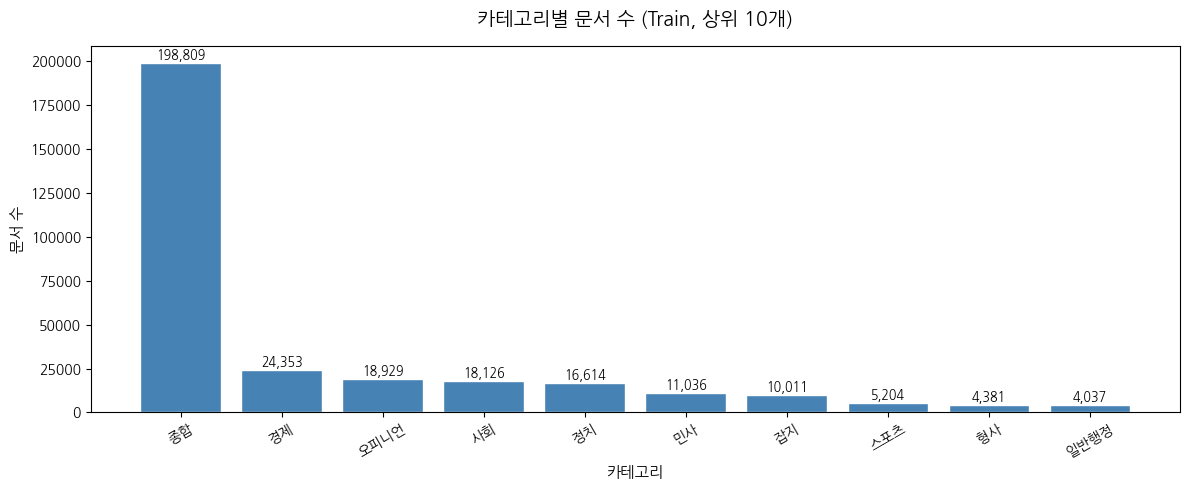

In [ ]:
# 카테고리 분포
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

categories = Counter(doc['category'] for doc in train_docs)
print(f"카테고리 분포 (상위 10개):")
for cat, cnt in categories.most_common(10):
    print(f"  {cat}: {cnt}개")

top_categories = categories.most_common(10)
labels, counts = zip(*top_categories)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts, color='steelblue', edgecolor='white')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{count:,}',
            ha='center', va='bottom', fontsize=9)

ax.set_title('카테고리별 문서 수 (Train, 상위 10개)', fontsize=14, pad=15)
ax.set_xlabel('카테고리', fontsize=11)
ax.set_ylabel('문서 수', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

종합 카테고리가 약 60퍼센트로 압도적으로 많음을 보임

하지만 종합 카테고리가 정치, 경제, 사회 등을 모두 포함하는 개념이라서 오히려 다양한 도메인을 커버한다고 판단, 진행하기로 결정

## 2-5. 특수문자 노이즈 확인

In [ ]:
# 특수문자 노이즈 확인
special_chars = []
for doc in train_docs[:1000]:
    for sent in get_sentences(doc):
        chars = re.findall(r'[^\w\s가-힣a-zA-Z0-9.,?!%\'"(){}\[\]]', sent)
        special_chars.extend(chars)

from collections import Counter
print("특수문자 분포 (상위 20개):")
for char, cnt in Counter(special_chars).most_common(20):
    print(f"  '{char}': {cnt}개")

특수문자 분포 (상위 20개):
  '·': 34개
  '-': 20개
  ':': 17개
  '∼': 2개
  '「': 2개
  '」': 2개
  ';': 1개
  '/': 1개
  '~': 1개


관찰해보니 노이즈가 생각보다 적고, 종류가 명확했다.

대부분 의미있는 기호(단위, 수식/표현, 범위 표현 등)이고 빈도가 매우 낮으므로 토크나이저가 처리하도록 두기로 결정했다.

## 2-6. EDA 최종 결론

**필터링: 5문장 미만 문서 제거 (1.26% 누락)**

**max_len: 128 (95th percentile 기준)**

**특수문자/노이즈 제거: 생략 (데이터가 전반적으로 깔끔함)**

**카테고리 샘플링: 생략 (종합 카테고리가 다양한 도메인 포함)**

**단, 학습 시간 고려하여 train 데이터 일부만 사용 예정**

# 3\. 전처리

데이터가 잘 정제되어있어, 전처리에서는 문장 갯수가 5개 미만인 문서만 제거하는 작업을 거쳤다.

In [ ]:
# 문장 추출 함수
def get_sentences(doc):
    sentences = []
    for para in doc['text']:
        for sent in para:
            sentences.append(sent['sentence'])
    return sentences

# 문서 필터링 함수
def filter_docs(docs, min_sents=5):
    filtered = [doc for doc in docs if len(get_sentences(doc)) >= min_sents]
    print(f"필터링 전: {len(docs):,}개 → 필터링 후: {len(filtered):,}개 "
          f"(제거: {len(docs)-len(filtered):,}개)")
    return filtered

# train / valid 적용
train_filtered = filter_docs(train_docs)
valid_filtered = filter_docs(valid_docs)

필터링 전: 325,072개 → 필터링 후: 320,961개 (제거: 4,111개)
필터링 전: 40,134개 → 필터링 후: 39,298개 (제거: 836개)


# 4\. 토큰화

## KLUE-BERT Tokenizer
NAVER, 카카오 등 국내 주요 AI 기관이 공동 개발한 한국어 NLP 벤치마크(KLUE) 기반의 토크나이저로, WordPiece 방식으로 32,000개의 한국어 vocab을 구축하여 다양한 도메인의 한국어 텍스트를 효과적으로 토크나이징한다.

**선택 이유:**
- 뉴스, 사설, 법률 등 다양한 도메인 데이터로 학습하여 이번 데이터셋과 적합
- vocab 크기 32,000개로 KoBERT(8,002개) 대비 한국어 표현력이 풍부
- 현재 한국어 NLP에서 가장 널리 사용되는 베이스라인 토크나이저

In [ ]:
#토크나이저 로드(KLUE-BERT)
tokenizer = AutoTokenizer.from_pretrained('klue/bert-base')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
# 기본 정보 확인
print(f"vocab 크기: {tokenizer.vocab_size}")
print(f"[CLS] 토큰 ID: {tokenizer.cls_token_id}")
print(f"[SEP] 토큰 ID: {tokenizer.sep_token_id}")
print(f"[MASK] 토큰 ID: {tokenizer.mask_token_id}")
print(f"[PAD] 토큰 ID: {tokenizer.pad_token_id}")

# 실제 데이터에서 샘플 문장 가져오기
sample = get_sentences(train_filtered[0])[0]

tokens = tokenizer.tokenize(sample)
ids = tokenizer.encode(sample)

print(f"\n샘플 문장: {sample}")
print(f"토큰: {tokens}")
print(f"토큰 수: {len(ids)}")

vocab 크기: 32000
[CLS] 토큰 ID: 2
[SEP] 토큰 ID: 3
[MASK] 토큰 ID: 4
[PAD] 토큰 ID: 0

샘플 문장: 원고가 소속회사의 노동조합에서 분규가 발생하자 노조활동을 구실로 정상적인 근무를 해태하고,
토큰: ['원고', '##가', '소속', '##회사', '##의', '노동조합', '##에서', '분규', '##가', '발생', '##하', '##자', '노조', '##활', '##동', '##을', '구실', '##로', '정상', '##적인', '근무', '##를', '해태', '##하고', ',']
토큰 수: 27


# 5\. BERT

**학습 계획**

- 하이퍼파라미터
  - epochs: 5
  - batch_size: 256
  - lr: 1e-4
  - weight_decay: 1e-2
  - eval_steps: 200 (200스텝마다 validation 진행)

- 옵티마이저: AdamW

- 스케줄러: Warmup + Cosine Decay (`transformers.get_cosine_schedule_with_warmup` 활용)
  - Warmup: 전체 스텝의 10% 동안 lr을 0 → 1e-4 로 천천히 올림 (초기 불안정한 학습 방지)
  - Cosine Decay: 이후 lr을 코사인 곡선으로 0까지 천천히 내림 (안정적 수렴)

## 5-1. 데이터셋 구성

**학습 방식: MLM + SOP**
- NSP(Next Sentence Prediction) 대신 ALBERT에서 제안한 SOP(Sentence Order Prediction) 방식 채택
- NSP는 랜덤 문장을 가져와 주제만 봐도 판별 가능한 반면, SOP는 같은 문서 내 문장 순서를 뒤집어 진짜 문맥 이해가 필요한 더 어려운 태스크
- MLM과 SOP를 동시에 사전학습하여 단어 수준(MLM) + 문장 간 관계(SOP) 모두 학습

**데이터 크기**
- Train: 전체 320,961개 중 30,000개 문서만 사용 (학습 시간 고려)
- Valid: 전체 39,298개 사용

**SOP 쌍 구성 방식**
- 문서당 3쌍 샘플링 → 총 180,000쌍 (긍정 90000 + 부정 90,000)
- 긍정 (label=0): 문서 내 연속된 문장 쌍 (올바른 순서)
- 부정 (label=1): 긍정 쌍을 뒤집어 순서를 바꾼 문장 쌍

**손실 함수**
- MLM: CrossEntropyLoss (ignore_index=-100) / math.log(vocab_size) 로 정규화
  - MLM loss가 SOP loss보다 스케일이 훨씬 커서 SOP 학습을 압도하는 문제 방지
- SOP: CrossEntropyLoss (이진 분류)
- 최종 손실: mlm_loss / math.log(vocab_size) + sop_loss

**입력 형식**
- [CLS] 문장A [SEP] 문장B [SEP] 형태로 구성
- max_len=128로 패딩/트런케이션 적용

**MLM 마스킹 전략**
- 전체 토큰의 15% 선택
- 선택된 토큰 중 80% → [MASK] 교체, 10% → 랜덤 토큰, 10% → 그대로 유지
- [CLS], [SEP], [PAD] 스페셜 토큰은 마스킹 제외

In [ ]:
# BERT 데이터셋
class BERTDataset(Dataset):
    def __init__(self, docs, tokenizer, max_len=128, pairs_per_doc=3):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.pairs = []
        self._build_pairs(docs, pairs_per_doc)

    def _build_pairs(self, docs, pairs_per_doc):
        for doc in docs:
            sents = get_sentences(doc)
            if len(sents) < 2:
                continue
            indices = list(range(len(sents) - 1))
            sampled = random.sample(indices, min(pairs_per_doc, len(indices)))
            for idx in sampled:
                sent_a = sents[idx]
                sent_b = sents[idx + 1]
                # 긍정: 올바른 순서 (label=0)
                self.pairs.append((sent_a, sent_b, 0))
                # 부정: 뒤집힌 순서 (label=1)
                self.pairs.append((sent_b, sent_a, 1))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        sent_a, sent_b, label = self.pairs[idx]
        encoded = self.tokenizer(
            sent_a, sent_b,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].squeeze(0)
        attention_mask = encoded['attention_mask'].squeeze(0)
        return input_ids, attention_mask, torch.tensor(label, dtype=torch.long)


In [ ]:
# 데이터셋 생성
random.seed(42) #랜덤값 고정
train_sample = random.sample(train_filtered, 30000)

special_token_ids = [
    tokenizer.cls_token_id,
    tokenizer.sep_token_id,
    tokenizer.pad_token_id
]
mask_id = tokenizer.mask_token_id
vocab_size = tokenizer.vocab_size

train_dataset = BERTDataset(train_sample, tokenizer, max_len=128, pairs_per_doc=3)
valid_dataset = BERTDataset(valid_filtered, tokenizer, max_len=128, pairs_per_doc=3)

print(f"Train 데이터셋 크기: {len(train_dataset):,}개")
print(f"Valid 데이터셋 크기: {len(valid_dataset):,}개")

# 샘플 확인
input_ids, attn_mask, label = train_dataset[0]
print(f"\n입력 shape: {input_ids.shape}")
print(f"레이블: {label.item()} ({'올바른 순서' if label.item()==0 else '뒤집힌 순서'})")
print(f"토큰: {tokenizer.convert_ids_to_tokens(input_ids[:20].tolist())}")

Train 데이터셋 크기: 180,000개
Valid 데이터셋 크기: 235,788개

입력 shape: torch.Size([128])
레이블: 0 (올바른 순서)
토큰: ['[CLS]', '이', '추세', '##대로', '##면', '역전', '##당', '##하', '##는', '것', '##은', '시간', '##문제', '##다', '.', '[SEP]', '블록체인', '·', 'AI', '·']


## 5-2. 모델링

In [ ]:
#멀티헤드 블록
class MTBlock(nn.Module):
    def __init__(self, em_dim, nhead, feed_dim=512, dropout=0.1):
        super(MTBlock, self).__init__()

        # 멀티헤드 셀프 어텐션 (batch_first=True: batch, seq, dim 순서로 입력)
        self.mha = nn.MultiheadAttention(em_dim, nhead, dropout=dropout, batch_first=True)

        # FFN: em_dim → feed_dim → em_dim, GELU 활성화 함수 사용
        self.ffn = nn.Sequential(
            nn.Linear(em_dim, feed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(feed_dim, em_dim)
        )

        # 어텐션 후, FFN 후 각각 LayerNorm 적용
        self.norm1 = nn.LayerNorm(em_dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(em_dim, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, attn_mask = None, key_padding_mask = None):

        # 셀프 어텐션: Q=K=V=x, 패딩 위치는 mask로 무시
        attn_output, _ = self.mha(x, x, x, attn_mask=attn_mask, key_padding_mask=key_padding_mask, need_weights=False)
        attn_output = self.dropout1(attn_output)

        # Skip Connection + LayerNorm
        out1 = self.norm1(x + attn_output)

        # FFN 통과 후 Skip Connection + LayerNorm
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)
        return out2

In [ ]:
#포지셔널 인코딩
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_pos=512):
        super().__init__()
        # 위치 인덱스 (max_pos, 1)
        position = torch.arange(max_pos).unsqueeze(1)
        # 차원별 주파수: exp+log 조합으로 10000^(2i/d) 계산
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim)
        )
        pe = torch.zeros(1, max_pos, embed_dim)
        # 짝수 차원 → sin, 홀수 차원 → cos
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        # 학습 안 되는 고정값으로 저장 (역전파 시 업데이트 X)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # 실제 시퀀스 길이만큼만 슬라이싱 후 더하기
        x = x + self.pe[:, :x.size(1), :]
        return x

(실험 중 추가) : 초기에는 Segment Embedding 없이 Token Embedding과 Positional Embedding만으로 진행했는데, [CLS] 벡터가 문장A/문장B의 순서 정보를 구분하지 못해 SOP Accuracy가 **랜덤 베이스라인(0.5)에서 전혀 개선되지 않는 문제가 발생**하여,

**[SEP] 토큰을 기준으로 문장A(0)와 문장B(1)를 명시적으로 구분하는 Segment Embedding을 추가하게 되었다.**

In [ ]:
class NewsDocBERT(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4,
                 feed_dim=256, num_layers=4, num_classes=2, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim

        # 토큰 ID → 임베딩 벡터
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim)

        # 문장A(0) / 문장B(1) 구분 신호
        self.segment_emb = nn.Embedding(2, embed_dim)

        # 인코더 블록 num_layers개 (ModuleList로 파라미터 등록)
        self.layers = nn.ModuleList([
            MTBlock(embed_dim, num_heads, feed_dim, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        # MLM 헤드: 각 토큰 위치에서 vocab 분류
        self.mlm_head = nn.Linear(embed_dim, vocab_size)

        # SOP 헤드: [CLS] 위치에서 문장 순서 이진 분류
        self.sop_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x, mask=None):
        device = x.device

        # [SEP] 기준으로 문장A(0)/문장B(1) 구분
        sep_id = 3  # tokenizer.sep_token_id
        segment_ids = (x == sep_id).cumsum(dim=1).clamp(max=1)

        # 토큰 임베딩 + 세그먼트 임베딩 + 포지셔널 인코딩
        scale = torch.sqrt(torch.tensor(self.embed_dim, dtype=torch.float, device=device))
        x = self.token_emb(x) * scale + self.segment_emb(segment_ids)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # 인코더 블록 순차 통과
        for layer in self.layers:
            x = layer(x, key_padding_mask=mask)

        # MLM: 모든 토큰 위치 예측
        mlm_logits = self.mlm_head(x)       # (batch, seq_len, vocab_size)

        # SOP: [CLS](0번 위치)가 문장 전체 의미 압축
        cls_emb = x[:, 0]                   # (batch, embed_dim)
        sop_logits = self.sop_head(cls_emb) # (batch, 2)
        return mlm_logits, sop_logits

## 5-3. 모델 생성 / 하이퍼파라미터

In [ ]:
# 하이퍼파라미터
vocab_size   = tokenizer.vocab_size  # 32,000
embed_dim    = 256
num_heads    = 8
feed_dim     = 512
num_layers   = 6
num_classes  = 2
dropout      = 0.1
batch_size   = 256
max_len      = 128
epochs       = 5
lr           = 1e-4
weight_decay = 1e-2
warmup_ratio = 0.1   # 전체 스텝의 10%를 warmup으로 사용
eval_steps   = 200   # 몇 스텝마다 평가할지

# 모델 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NewsDocBERT(vocab_size, embed_dim, num_heads, feed_dim, num_layers, num_classes, dropout).to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 수: {total_params:,}")
print(f"device: {device}")

총 파라미터 수: 19,579,650
device: cuda


In [ ]:
# 데이터로더 생성

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

print(f"Train 데이터셋: {len(train_dataset):,}개")
print(f"Valid 데이터셋: {len(valid_dataset):,}개")
print(f"Train 배치 수: {len(train_loader):,}")
print(f"Valid 배치 수: {len(valid_loader):,}")

Train 데이터셋: 180,000개
Valid 데이터셋: 235,788개
Train 배치 수: 704
Valid 배치 수: 922


## 5-4. 모델 학습

In [ ]:
# MLM 마스킹 함수
def mask_tokens_for_mlm(input_ids, special_token_ids, mask_id, vocab_size, mlm_prob=0.15):
    labels = torch.full(input_ids.shape, -100, dtype=torch.long)

    for i in range(input_ids.size(0)):
        for j in range(input_ids.size(1)):
            # 스페셜 토큰은 마스킹 제외
            if input_ids[i][j].item() in special_token_ids:
                continue
            if random.random() < mlm_prob:
                labels[i][j] = input_ids[i][j].clone()
                r = random.random()
                if r < 0.8:
                    # 80% → [MASK] 교체
                    input_ids[i][j] = mask_id
                elif r < 0.9:
                    # 10% → 랜덤 토큰
                    input_ids[i][j] = random.randint(0, vocab_size - 1)
                # 10% → 그대로 유지
    return input_ids, labels

In [ ]:
# 스페셜 토큰 / 마스크 토큰 설정
special_token_ids = [tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id]
mask_id = tokenizer.mask_token_id

# 옵티마이저
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# 스케줄러: Warmup + Cosine Decay
total_steps  = epochs * len(train_loader)
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# 손실 함수
mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)  # 마스킹된 자리만 계산
sop_loss_fn = nn.CrossEntropyLoss()                   # 이진 분류


시간 단축용으로 손실 평가시에 전체를 평가하지 않고, 100배치만 평가를 시행했다.

(실험 중 추가)
- MLM loss가 SOP loss보다 약 10배 이상 커서 역전파 시 SOP 그래디언트가 묻혀 SOP 학습이 이루어지지 않았다. 이를 해결하기 위해 MLM loss를 math.log(vocab_size)로 나누어 두 손실의 스케일을 맞추는 정규화를 적용하였다.

In [ ]:
# 학습 기록
BERT_history = {
    'train_mlm_loss': [],
    'train_sop_loss': [],
    'train_loss':     [],
    'val_sop_loss':   [],
    'val_sop_acc':    [],
    'step':           []
}

print(f"전체 스텝 수: {total_steps:,}")
print(f"Warmup 스텝 수: {warmup_steps:,}")

# 학습 루프
global_step = 0
model.train()

for epoch in range(epochs):
    epoch_start = time.time()  # 에포크 시작 시간
    t_mlm_loss = 0.0
    t_sop_loss = 0.0

    for step, (input_ids, attn_mask, sop_label) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        sop_label = sop_label.to(device)

        # MLM 마스킹 적용
        mlm_input, mlm_labels = mask_tokens_for_mlm(
            input_ids.clone(), special_token_ids, mask_id, vocab_size
        )
        mlm_labels = mlm_labels.to(device)

        # 패딩 마스크: PAD 위치는 True
        padding_mask = (attn_mask == 0)

        # forward
        mlm_logits, sop_logits = model(mlm_input, mask=padding_mask)

        # 손실 계산
        mlm_loss = mlm_loss_fn(mlm_logits.view(-1, vocab_size), mlm_labels.view(-1))
        sop_loss = sop_loss_fn(sop_logits, sop_label)
        loss = mlm_loss / math.log(vocab_size) + sop_loss

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        t_mlm_loss += mlm_loss.item()
        t_sop_loss += sop_loss.item()
        global_step += 1

        # eval_steps마다 평가
        if global_step % eval_steps == 0:
            avg_mlm  = t_mlm_loss / eval_steps
            avg_sop  = t_sop_loss / eval_steps
            avg_loss = avg_mlm + avg_sop

            # 직전 200스텝 손실 초기화
            t_mlm_loss = 0.0
            t_sop_loss = 0.0

            # validation SOP Accuracy
            val_acc = 0.0
            val_loss = 0.0
            model.eval()
            with torch.no_grad():
                for i, (val_ids, val_mask, val_label) in enumerate(valid_loader):
                    if i >= 100:  # 100배치만 평가
                        break
                    val_ids   = val_ids.to(device)
                    val_mask  = val_mask.to(device)
                    val_label = val_label.to(device)
                    _, val_sop = model(val_ids, mask=(val_mask == 0))
                    val_loss += sop_loss_fn(val_sop, val_label).item()
                    val_acc += (val_sop.argmax(dim=1) == val_label).sum().item() / len(val_label)
                val_loss /= 100
                val_acc  /= 100
            model.train()

            # 기록 저장
            BERT_history['train_mlm_loss'].append(avg_mlm)
            BERT_history['train_sop_loss'].append(avg_sop)
            BERT_history['train_loss'].append(avg_loss)
            BERT_history['val_sop_loss'].append(val_loss)
            BERT_history['val_sop_acc'].append(val_acc)
            BERT_history['step'].append(global_step)

            print(f"Epoch {epoch+1} | Step {global_step:,} | "
                  f"MLM Loss: {avg_mlm:.4f} | Train SOP Loss: {avg_sop:.4f} | "
                  f"Val SOP Loss: {val_loss:.4f} | Val SOP Acc: {val_acc:.4f}")
    # 에포크 소요 시간
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1} 완료 | 소요 시간: {epoch_time/60:.1f}분\n")


전체 스텝 수: 3,520
Warmup 스텝 수: 352
Epoch 1 | Step 200 | MLM Loss: 10.0097 | Train SOP Loss: 0.7321 | Val SOP Loss: 0.6948 | Val SOP Acc: 0.5008
Epoch 1 | Step 400 | MLM Loss: 7.8391 | Train SOP Loss: 0.6983 | Val SOP Loss: 0.6934 | Val SOP Acc: 0.5039
Epoch 1 | Step 600 | MLM Loss: 7.3926 | Train SOP Loss: 0.6962 | Val SOP Loss: 0.6941 | Val SOP Acc: 0.5002

Epoch 1 완료 | 소요 시간: 13.7분

Epoch 2 | Step 800 | MLM Loss: 3.5411 | Train SOP Loss: 0.3343 | Val SOP Loss: 0.6939 | Val SOP Acc: 0.5002
Epoch 2 | Step 1,000 | MLM Loss: 7.3691 | Train SOP Loss: 0.6951 | Val SOP Loss: 0.6931 | Val SOP Acc: 0.5030
Epoch 2 | Step 1,200 | MLM Loss: 7.3570 | Train SOP Loss: 0.6958 | Val SOP Loss: 0.6932 | Val SOP Acc: 0.5032
Epoch 2 | Step 1,400 | MLM Loss: 7.3269 | Train SOP Loss: 0.6951 | Val SOP Loss: 0.6931 | Val SOP Acc: 0.5039

Epoch 2 완료 | 소요 시간: 14.0분

Epoch 3 | Step 1,600 | MLM Loss: 7.0130 | Train SOP Loss: 0.6671 | Val SOP Loss: 0.6934 | Val SOP Acc: 0.5029
Epoch 3 | Step 1,800 | MLM Loss: 7.2791

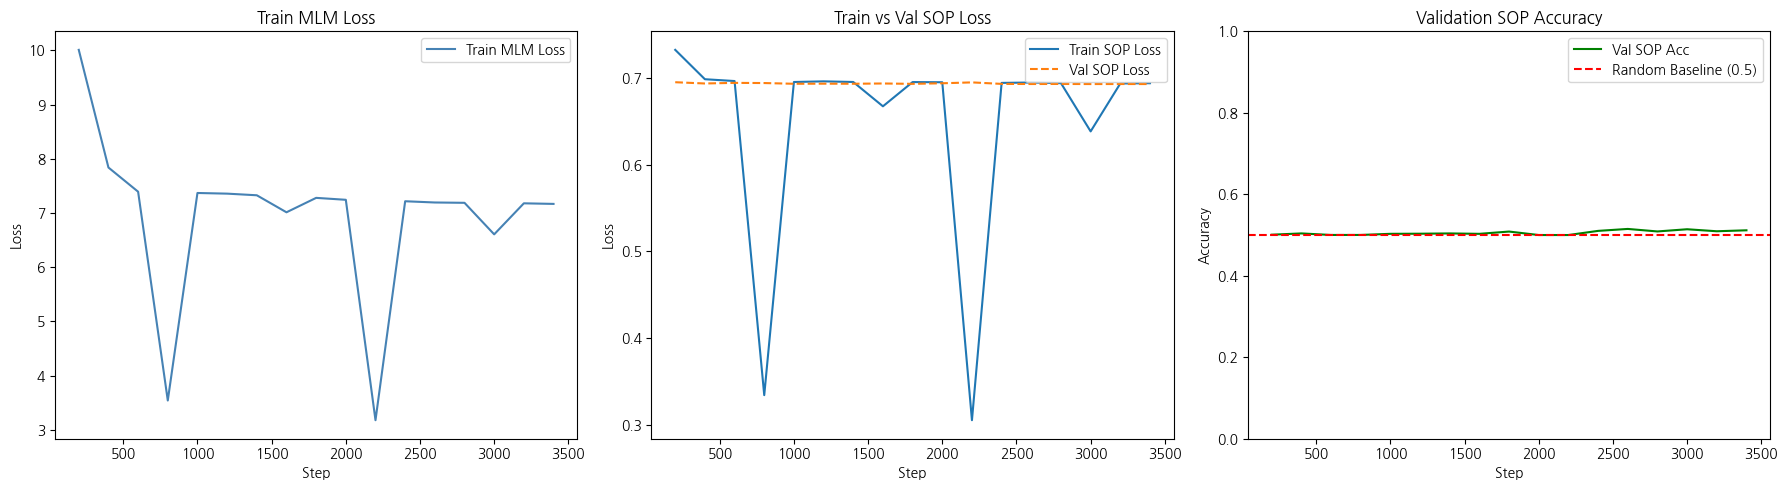

In [ ]:
#손실 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train MLM Loss
axes[0].plot(BERT_history['step'], BERT_history['train_mlm_loss'], label='Train MLM Loss', color='steelblue')
axes[0].set_title('Train MLM Loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Train vs Val SOP Loss → 과적합 판단
axes[1].plot(BERT_history['step'], BERT_history['train_sop_loss'], label='Train SOP Loss')
axes[1].plot(BERT_history['step'], BERT_history['val_sop_loss'], label='Val SOP Loss', linestyle='--')
axes[1].set_title('Train vs Val SOP Loss')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].legend()

# SOP Accuracy
axes[2].plot(BERT_history['step'], BERT_history['val_sop_acc'], color='green', label='Val SOP Acc')
axes[2].axhline(y=0.5, color='red', linestyle='--', label='Random Baseline (0.5)')
axes[2].set_title('Validation SOP Accuracy')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()

## 5-5. 평가

**평가 지표 선택 이유**

- SOP Accuracy: BERT의 문장 간 관계 이해 능력을 직접 측정하는 지표로, SOP 사전학습 태스크의 성능을 가장 직관적으로 확인 가능
- MLM Perplexity: BERT의 언어 이해 능력을 측정하는 지표로, MLM 사전학습 태스크의 품질을 val loss로부터 간단하게 계산 가능
- 두 지표를 함께 사용하면 단어 수준 이해(MLM)와 문장 간 관계 이해(SOP)를 모두 평가 가능

**평가 기준**

| 지표 | 낮음 | 보통 | 좋음 | 매우 좋음 |
|---|---|---|---|---|
| SOP Accuracy | ~0.6 | 0.6~0.75 | 0.75~0.9 | 0.9~ |
| MLM Perplexity | 1000~ | 100~1000 | 10~100 | ~10 |

> SOP는 랜덤 예측 시 0.5가 baseline이므로 0.6 미만이면 학습이 제대로 안 된 것

> MLM Perplexity는 vocab 크기와 도메인에 따라 절대값이 달라지므로 학습 추이로 판단

In [ ]:
# 최종 평가
model.eval()
total_acc = 0.0
total_mlm_loss = 0.0

with torch.no_grad():
    for input_ids, attn_mask, sop_label in valid_loader:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        sop_label = sop_label.to(device)

        # MLM 마스킹 적용
        mlm_input, mlm_labels = mask_tokens_for_mlm(
            input_ids.clone(), special_token_ids, mask_id, vocab_size
        )
        mlm_labels = mlm_labels.to(device)

        padding_mask = (attn_mask == 0)
        mlm_logits, sop_logits = model(mlm_input, mask=padding_mask)

        # MLM loss 계산
        mlm_loss = mlm_loss_fn(mlm_logits.view(-1, vocab_size), mlm_labels.view(-1))
        total_mlm_loss += mlm_loss.item()

        # SOP Accuracy 계산
        total_acc += (sop_logits.argmax(dim=1) == sop_label).sum().item() / len(sop_label)

sop_acc       = total_acc / len(valid_loader)
avg_mlm_loss  = total_mlm_loss / len(valid_loader)
mlm_perplexity = math.exp(avg_mlm_loss)

print(f"SOP Accuracy:    {sop_acc:.4f}")
print(f"MLM Loss:        {avg_mlm_loss:.4f}")
print(f"MLM Perplexity:  {mlm_perplexity:.2f}")

SOP Accuracy:    0.5085
MLM Loss:        7.1605
MLM Perplexity:  1287.50


## 5-6. BERT 평가 결론

| 지표 | 결과 | 기준 | 평가 |
|---|---|---|---|
| SOP Accuracy | 0.5084 | 0.6 미만: 낮음 |  랜덤 베이스라인(0.5) 수준 |
| MLM Perplexity | 1,292 | 1000~: 낮음 |  학습은 됐으나 충분하지 않음 |

**손실 분석:**
- MLM Loss: 10.01 → 7.17 (5에포크 동안 꾸준히 감소)
- Train SOP Loss ≈ Val SOP Loss ≈ 0.69 (전 에포크 동안 변화 없음)
- Train/Val SOP Loss가 거의 동일하여 과적합은 없으나 학습 자체가 이루어지지 않음

**원인 분석:**
- MLM Perplexity가 초기 랜덤 수준(~32,000)에서 1,292로 감소하여 언어 이해 능력은 학습됨
- SOP Accuracy는 랜덤 베이스라인(0.5)에서 거의 벗어나지 못함
- 데이터 부족(30,000문서), 모델 크기 한계(1,950만 파라미터), 학습량 부족이 주요 원인
- BERT 원논문 대비 데이터와 모델 규모가 크게 작아 성능 한계가 명확함

# 6\. GPT

**학습 계획**

- 하이퍼파라미터 (BERT와 동일)
  - epochs: 5
  - batch_size: 256
  - lr: 1e-4
  - weight_decay: 1e-2
  - eval_steps: 200 (200스텝마다 validation 진행)

- 옵티마이저: AdamW

- 스케줄러: Warmup + Cosine Decay (`transformers.get_cosine_schedule_with_warmup` 활용)

- 손실 함수
  - CrossEntropyLoss (ignore_index=pad_token_id, 패딩 토큰 무시)
  - BERT와 달리 손실이 하나 (다음 토큰 예측만)
  - 최종 손실: train loss vs val loss 비교로 과적합 판단

## 6-1. 데이터셋 구성

**데이터 크기**
- Train: BERT와 동일하게 100,000개 문서 사용
- Valid: 전체 39,298개 사용

**청크 구성 방식**
- 문서 내 모든 문장을 토큰화 후 이어붙여 긴 시퀀스 생성
- max_len=128 단위로 청크 분할
- 마지막 청크가 max_len보다 짧으면 패딩으로 채움

In [ ]:
#GPT 데이터셋 클래스
class GPTDataset(Dataset):
    def __init__(self, docs, tokenizer, max_len=128):
        self.max_len = max_len
        self.input_ids  = []
        self.target_ids = []
        self.attn_masks = []
        self._build_chunks(docs, tokenizer)

    def _build_chunks(self, docs, tokenizer):
        pad_id = tokenizer.pad_token_id

        for doc in docs:
            # 문서 내 모든 문장을 이어붙여 하나의 토큰 시퀀스 생성
            sents = get_sentences(doc)
            full_text = ' '.join(sents)
            tokens = tokenizer.encode(full_text, add_special_tokens=False)

            # max_len+1 단위로 청크 분할
            for i in range(0, len(tokens), self.max_len):
                chunk = tokens[i:i + self.max_len + 1]

                if len(chunk) < 2:
                    continue

                # input=tokens[:-1], target=tokens[1:] (한 칸 밀린 관계)
                input_chunk  = chunk[:-1]
                target_chunk = chunk[1:]

                # max_len보다 짧으면 패딩
                pad_len = self.max_len - len(input_chunk)
                attn_mask    = [1] * len(input_chunk) + [0] * pad_len
                input_chunk  = input_chunk  + [pad_id] * pad_len
                target_chunk = target_chunk + [pad_id] * pad_len

                self.input_ids.append(input_chunk)
                self.target_ids.append(target_chunk)
                self.attn_masks.append(attn_mask)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.input_ids[idx],  dtype=torch.long),
            torch.tensor(self.target_ids[idx], dtype=torch.long),
            torch.tensor(self.attn_masks[idx], dtype=torch.long)
        )


In [ ]:
# 데이터셋 생성
gpt_train_dataset = GPTDataset(train_sample, tokenizer, max_len=max_len)
gpt_valid_dataset = GPTDataset(valid_filtered, tokenizer, max_len=max_len)

# 데이터로더 생성
gpt_train_loader = DataLoader(gpt_train_dataset, batch_size=batch_size, shuffle=True)
gpt_valid_loader = DataLoader(gpt_valid_dataset, batch_size=batch_size, shuffle=False)

print(f"Train 데이터셋: {len(gpt_train_dataset):,}개")
print(f"Valid 데이터셋: {len(gpt_valid_dataset):,}개")
print(f"Train 배치 수: {len(gpt_train_loader):,}")
print(f"Valid 배치 수: {len(gpt_valid_loader):,}")

Token indices sequence length is longer than the specified maximum sequence length for this model (650 > 512). Running this sequence through the model will result in indexing errors


Train 데이터셋: 137,889개
Valid 데이터셋: 180,530개
Train 배치 수: 539
Valid 배치 수: 706


KLUE-BERT가 사전학습할때 최대 512토큰으로 학습하여, 기본 최대길이가 512로 설정되어있어 경고 발생

-> BUT 문서 전체를 이어붙이게 되면 512토큰을 초과하는 경우가 있지만, 어차피 청크로 잘라서 max_len(128)로 넣기 때문에 상관없다.

## 6-2. 모델링

In [ ]:
#GPT 클래스 정의
class NewsDocGPT(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4,
                 feed_dim=256, num_layers=4, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim

        # 토큰 임베딩 + 포지셔널 인코딩
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim)
        self.dropout = nn.Dropout(dropout)

        # 디코더 블록 num_layers개 (causal mask 적용)
        self.layers = nn.ModuleList([
            MTBlock(embed_dim, num_heads, feed_dim, dropout=dropout)
            for _ in range(num_layers)
        ])

        # 다음 토큰 예측 헤드
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x, key_padding_mask=None):
        bsz, seq_len = x.shape
        device = x.device

        # √embed_dim 스케일링
        scale = torch.sqrt(torch.tensor(self.embed_dim, dtype=torch.float, device=device))
        x = self.token_emb(x) * scale
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # Causal Mask: 미래 토큰을 보지 못하도록 상삼각 행렬로 차단
        causal_mask = torch.ones(seq_len, seq_len, dtype=torch.bool, device=device)
        causal_mask = torch.triu(causal_mask, diagonal=1)

        # 디코더 블록 순차 통과
        for layer in self.layers:
            x = layer(x, attn_mask=causal_mask, key_padding_mask=key_padding_mask)

        # 모든 토큰 위치에서 다음 토큰 예측
        logits = self.lm_head(x)  # (batch, seq_len, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, start_tokens, tokenizer, max_new_tokens=50):
        self.eval()
        generated = start_tokens.clone()

        for _ in range(max_new_tokens):
            logits = self.forward(generated)

            # 마지막 위치의 로짓으로 다음 토큰 예측
            next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)

            # EOS 토큰 나오면 중단
            if next_token.item() == tokenizer.sep_token_id:
                break

        return tokenizer.decode(generated[0].tolist(), skip_special_tokens=True)

    #Temperatue + Top-K Sampling 생성 함수
    @torch.no_grad()
    def generate_topk(self, start_tokens, tokenizer,
                      max_new_tokens=50, top_k=50, temperature=0.7):
        self.eval()
        generated = start_tokens.clone()

        for _ in range(max_new_tokens):
            logits = self.forward(generated)

            # Temperature 적용 후 Top-k 필터링
            logits = logits[:, -1, :] / temperature
            top_k_logits, top_k_indices = logits.topk(top_k)
            probs = torch.softmax(top_k_logits, dim=-1)

            # 확률 분포에서 샘플링
            next_token_idx = torch.multinomial(probs, num_samples=1)
            next_token = top_k_indices.gather(-1, next_token_idx)
            generated = torch.cat([generated, next_token], dim=1)

            if next_token.item() == tokenizer.sep_token_id:
                break

        return tokenizer.decode(generated[0].tolist(), skip_special_tokens=True)

## 6-3. 모델 생성 / 하이퍼파라미터

In [ ]:
# 하이퍼파라미터 (BERT와 동일한 설정 사용)
# vocab_size, embed_dim, num_heads, feed_dim, num_layers,
# dropout, batch_size, max_len, epochs, lr, weight_decay,
# warmup_ratio, eval_steps 위에서 이미 정의됨

# 모델 생성
gpt_model = NewsDocGPT(
    vocab_size = vocab_size,
    embed_dim  = embed_dim,
    num_heads  = num_heads,
    feed_dim   = feed_dim,
    num_layers = num_layers,
    dropout    = dropout
).to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in gpt_model.parameters())
print(f"총 파라미터 수: {total_params:,}")
print(f"device: {device}")

총 파라미터 수: 19,578,624
device: cuda


## 6-4. 모델 학습

In [ ]:
# 옵티마이저 (BERT와 동일한 설정)
gpt_optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=lr, weight_decay=weight_decay)

# 스케줄러: Warmup + Cosine Decay
gpt_total_steps  = epochs * len(gpt_train_loader)
gpt_warmup_steps = int(gpt_total_steps * warmup_ratio)
gpt_scheduler = get_cosine_schedule_with_warmup(
    gpt_optimizer,
    num_warmup_steps=gpt_warmup_steps,
    num_training_steps=gpt_total_steps
)

# 손실 함수: 패딩 토큰 무시
gpt_loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

In [ ]:
# 학습 기록
GPT_history = {
    'train_loss': [],
    'val_loss':   [],
    'step':       []
}

print(f"전체 스텝 수: {gpt_total_steps:,}")
print(f"Warmup 스텝 수: {gpt_warmup_steps:,}")

# 학습 루프
global_step = 0
gpt_model.train()

for epoch in range(epochs):
    epoch_start = time.time()
    t_loss = 0.0

    for step, (input_ids, target_ids, attn_mask) in enumerate(gpt_train_loader):
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)
        attn_mask  = attn_mask.to(device)

        # 패딩 마스크: PAD 위치는 True
        padding_mask = (attn_mask == 0)

        # forward
        logits = gpt_model(input_ids, key_padding_mask=padding_mask)

        # 손실 계산: (B*L, vocab_size) vs (B*L,)
        loss = gpt_loss_fn(logits.view(-1, vocab_size), target_ids.view(-1))

        # 역전파
        gpt_optimizer.zero_grad()
        loss.backward()
        gpt_optimizer.step()
        gpt_scheduler.step()

        t_loss += loss.item()
        global_step += 1

        # eval_steps마다 평가
        if global_step % eval_steps == 0:
            avg_loss = t_loss / eval_steps

            # 직전 500스텝 손실 초기화
            t_loss = 0.0

            # validation loss
            val_loss = 0.0
            gpt_model.eval()
            with torch.no_grad():
                for i, (val_inp, val_tar, val_mask) in enumerate(gpt_valid_loader):
                    if i >= 100:  # 100배치만 평가
                        break
                    val_inp  = val_inp.to(device)
                    val_tar  = val_tar.to(device)
                    val_mask = val_mask.to(device)
                    val_logits = gpt_model(val_inp, key_padding_mask=(val_mask == 0))
                    val_loss += gpt_loss_fn(val_logits.view(-1, vocab_size), val_tar.view(-1)).item()
            val_loss /= 100
            gpt_model.train()

            # 기록 저장
            GPT_history['train_loss'].append(avg_loss)
            GPT_history['val_loss'].append(val_loss)
            GPT_history['step'].append(global_step)

            print(f"Epoch {epoch+1} | Step {global_step:,} | "
                  f"Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

    # 에포크 소요 시간
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1} 완료 | 소요 시간: {epoch_time/60:.1f}분\n")

전체 스텝 수: 2,695
Warmup 스텝 수: 269
Epoch 1 | Step 200 | Train Loss: 9.3152 | Val Loss: 7.7270
Epoch 1 | Step 400 | Train Loss: 7.2297 | Val Loss: 6.9155

Epoch 1 완료 | 소요 시간: 2.1분

Epoch 2 | Step 600 | Train Loss: 1.9968 | Val Loss: 6.4724
Epoch 2 | Step 800 | Train Loss: 6.3490 | Val Loss: 6.2088
Epoch 2 | Step 1,000 | Train Loss: 6.1272 | Val Loss: 6.0308

Epoch 2 완료 | 소요 시간: 2.2분

Epoch 3 | Step 1,200 | Train Loss: 3.6305 | Val Loss: 5.9067
Epoch 3 | Step 1,400 | Train Loss: 5.8668 | Val Loss: 5.8223
Epoch 3 | Step 1,600 | Train Loss: 5.8010 | Val Loss: 5.7583

Epoch 3 완료 | 소요 시간: 2.2분

Epoch 4 | Step 1,800 | Train Loss: 5.2539 | Val Loss: 5.7143
Epoch 4 | Step 2,000 | Train Loss: 5.7041 | Val Loss: 5.6872

Epoch 4 완료 | 소요 시간: 2.1분

Epoch 5 | Step 2,200 | Train Loss: 1.2468 | Val Loss: 5.6722
Epoch 5 | Step 2,400 | Train Loss: 5.6741 | Val Loss: 5.6644
Epoch 5 | Step 2,600 | Train Loss: 5.6684 | Val Loss: 5.6622

Epoch 5 완료 | 소요 시간: 2.2분



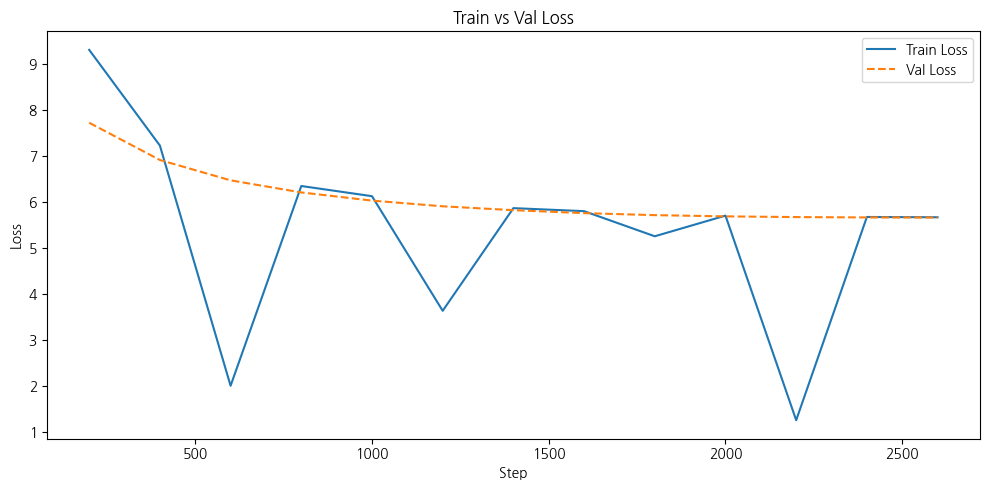

In [ ]:
# 손실 시각화
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(GPT_history['step'], GPT_history['train_loss'], label='Train Loss')
ax.plot(GPT_history['step'], GPT_history['val_loss'],   label='Val Loss', linestyle='--')
ax.set_title('Train vs Val Loss')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.legend()

plt.tight_layout()
plt.show()

**그래프 분석:**
- Val Loss가 7.7 → 5.6으로 꾸준히 감소하며 안정적인 학습 곡선을 보임
- Train Loss의 급격한 하락 지점(Step 600, 1200, 2200)은 에포크 경계에서
  스텝이 덜 누적된 채 평균을 계산하여 발생한 현상으로 실제 학습과 무관
- 후반부(Step 1500~)에서 Train ≈ Val Loss로 과적합 없이 안정적으로 수렴

## 6-5. GPT 평가

**평가 지표**

- Perplexity: 모델이 텍스트를 얼마나 잘 예측하는지 (낮을수록 좋음)
  - PPL = exp(CrossEntropyLoss)
- BLEU Score: 생성 텍스트가 원문과 얼마나 유사한지 (높을수록 좋음)
  - validation 데이터에서 50토큰을 입력으로 하여 생성된 텍스트를 원문과 비교

**평가 지표 선택 이유**

- Perplexity: 언어 모델의 학습 품질을 직접적으로 측정하는 지표로, val loss로부터 계산 가능하여 별도 생성 없이 빠르게 평가 가능
- BLEU Score: 실제 생성된 텍스트가 원문과 얼마나 유사한지 측정하여 Perplexity만으로 알 수 없는 실제 생성 품질을 보완
- 두 지표를 함께 사용하면 학습 품질(Perplexity)과 실제 생성 품질(BLEU)을 모두 평가 가능


**평가 기준**

| 지표 | 낮음 | 보통 | 좋음 | 매우 좋음 |
|---|---|---|---|---|
| Perplexity | 1000~ | 100~1000 | 10~100 | ~10 |
| BLEU Score | ~0.1 | 0.1~0.3 | 0.3~0.5 | 0.5~ |

- Perplexity는 vocab 크기와 도메인에 따라 절대값이 달라지므로 학습 추이로 판단

- BLEU Score는 생성 길이가 짧을수록 낮게 나오는 경향이 있음

In [ ]:
#평가지표 출력

# Perplexity: val loss로부터 계산
total_loss = 0.0
gpt_model.eval()
with torch.no_grad():
    for val_inp, val_tar, val_mask in gpt_valid_loader:
        val_inp  = val_inp.to(device)
        val_tar  = val_tar.to(device)
        val_mask = val_mask.to(device)
        val_logits = gpt_model(val_inp, key_padding_mask=(val_mask == 0))
        total_loss += gpt_loss_fn(val_logits.view(-1, vocab_size), val_tar.view(-1)).item()

avg_loss   = total_loss / len(gpt_valid_loader)
perplexity = math.exp(avg_loss)

# BLEU: 50토큰 입력 → 생성 텍스트 vs 원문 비교
smoothing  = SmoothingFunction().method1
bleu_scores = []

for doc in valid_filtered[:100]:
    sents = get_sentences(doc)
    full_text = ' '.join(sents)
    tokens = tokenizer.encode(full_text, add_special_tokens=False)

    if len(tokens) < 60:
        continue

    # 50토큰 입력
    input_tokens = torch.tensor([tokens[:50]], dtype=torch.long).to(device)
    reference    = tokens[50:]

    # 텍스트 생성
    generated_text   = gpt_model.generate(input_tokens, tokenizer, max_new_tokens=50)
    generated_tokens = tokenizer.encode(generated_text, add_special_tokens=False)

    if len(generated_tokens) == 0:
        continue

    # BLEU 계산 (토큰 ID 단위)
    ref   = [str(t) for t in reference]
    hyp   = [str(t) for t in generated_tokens]
    score = sentence_bleu([ref], hyp, smoothing_function=smoothing)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0

print(f"Val Loss:   {avg_loss:.4f}")
print(f"Perplexity: {perplexity:.2f}")
print(f"BLEU Score: {avg_bleu:.4f}")


Val Loss:   5.5980
Perplexity: 269.89
BLEU Score: 0.0075


In [ ]:
# 실제 생성 텍스트 vs 원문 비교
gpt_model.eval()

for doc in valid_filtered[:3]:
    sents = get_sentences(doc)
    full_text = ' '.join(sents)
    tokens = tokenizer.encode(full_text, add_special_tokens=False)

    if len(tokens) < 60:
        continue

    # 50토큰 입력
    input_tokens = torch.tensor([tokens[:50]], dtype=torch.long).to(device)

    # 원문 (50토큰 이후)
    original_text = tokenizer.decode(tokens[50:100], skip_special_tokens=True)

    # 생성 텍스트
    generated_text = gpt_model.generate(input_tokens, tokenizer, max_new_tokens=50)

    # 입력 텍스트
    input_text = tokenizer.decode(tokens[:50], skip_special_tokens=True)

    print(f"입력:  {input_text}")
    print(f"원문:  {original_text}")
    print(f"생성:  {generated_text}")
    print("-" * 80)

입력:  [ 박재원 기자 ] ' 대한민국 5G 홍보대사 ' 를 자처한 문재인 대통령은 " 넓고, 체증 없는 ' 통신 고속도로 ' 가 5G " 라며 " 대한민국의 대전환이 이제 막 시작됐다 " 고 기대감을 높였
원문:  ##다. 문 대통령은 8일 서울 올림픽공원에서 열린 5G플러스 전략발표에 참석해 " 5G 시대는 우리가 생각하고, 만들면 그것이 세계 표준이 되는 시대 " 라며 " 5G는 대한민국 혁신성장
생성:  [ 박재원 기자 ] ' 대한민국 5G 홍보대사 ' 를 자처한 문재인 대통령은 " 넓고, 체증 없는 ' 통신 고속도로 ' 가 5G " 라며 " 대한민국의 대전환이 이제 막 시작됐다 " 고 기대감을 높였다. 이는 " 이번에 대한 관심을 하는 것 " 이라고 말했다. 이는 " 이번에 대한 관심을 받고 말했다. 이들은 " 이번에게 되는 것이 없다. 이들
--------------------------------------------------------------------------------
입력:  ] 당 지도부 퇴진을 놓고 바른미래당 내홍이 격화되고 있다. 바른미래당이 8일 연 최고위원 회의에는 7명의 최고위원 중 손학규 대표와 김관영 원내대표만 참석했다. 바른
원문:  ##정당계 하태경 · 이준석 · 권은희 최고위원은 지도부 총사퇴를 요구하며 회의를 보이콧했다. 국민의당 출신 권은희 정책위원회 의장과 김수민 최고위원은 개인 일정을 이유로 불참한 것으로
생성:  ] 당 지도부 퇴진을 놓고 바른미래당 내홍이 격화되고 있다. 바른미래당이 8일 연 최고위원 회의에는 7명의 최고위원 중 손학규 대표와 김관영 원내대표만 참석했다. 바른미래당은 " 이번에 대한 관심을 통해 " 이라고 말했다. 이에는 " 이번에 대한 관심을 통해 " 고 말했다. 이들은 " 며 " 이번에게 되는 " 고 말했다
--------------------------------------------------------------------------------
입력:  [ 홍윤정 기자 ] 8일

## (추가) Temperaute + Top-k Sampling


기존 generate 함수는 Greedy Decoding 방식으로 매 스텝마다 확률이 가장 높은 토큰만 선택하였다. 이로 인해 "을 통해", "이에는", "며" 등 고빈도 패턴이 반복되는 현상이 발생하였다. 이를 개선하기 위해 Top-k Sampling과 Temperature Sampling을 결합한 방식을 추가로 적용하였다.

- **Top-k Sampling**: 확률 상위 k개 토큰만 후보로 추려 그 중에서 랜덤 샘플링 (top_k=50)
- **Temperature Sampling**: logits을 temperature로 나눠 확률 분포를 조정 (temperature=0.7)
- 두 방법을 결합하여 반복 패턴을 완화하면서도 너무 엉뚱한 토큰이 선택되지 않도록 균형을 맞춤

In [ ]:
# BLEU Score 비교 (Greedy vs Top-k + Temperature)
smoothing = SmoothingFunction().method1

greedy_scores = []
topk_scores   = []

for doc in valid_filtered[:100]:
    sents = get_sentences(doc)
    full_text = ' '.join(sents)
    tokens = tokenizer.encode(full_text, add_special_tokens=False)

    if len(tokens) < 60:
        continue

    input_tokens = torch.tensor([tokens[:50]], dtype=torch.long).to(device)
    reference    = tokens[50:100]
    ref          = [str(t) for t in reference]

    # Greedy 생성
    greedy_text   = gpt_model.generate(input_tokens, tokenizer, max_new_tokens=50)
    greedy_tokens = tokenizer.encode(greedy_text, add_special_tokens=False)

    # Top-k + Temperature 생성
    topk_text   = gpt_model.generate_topk(input_tokens, tokenizer,
                                           max_new_tokens=50, top_k=50, temperature=0.7)
    topk_tokens = tokenizer.encode(topk_text, add_special_tokens=False)

    if len(greedy_tokens) > 0:
        greedy_scores.append(sentence_bleu([ref], [str(t) for t in greedy_tokens],
                                            smoothing_function=smoothing))
    if len(topk_tokens) > 0:
        topk_scores.append(sentence_bleu([ref], [str(t) for t in topk_tokens],
                                          smoothing_function=smoothing))

avg_greedy = sum(greedy_scores) / len(greedy_scores) if greedy_scores else 0.0
avg_topk   = sum(topk_scores)   / len(topk_scores)   if topk_scores   else 0.0

print(f"Greedy BLEU Score:          {avg_greedy:.4f}")
print(f"Top-k + Temperature BLEU:   {avg_topk:.4f}")
print(f"개선율: {((avg_topk - avg_greedy) / avg_greedy * 100):.1f}%")

Greedy BLEU Score:          0.0311
Top-k + Temperature BLEU:   0.0322
개선율: 3.5%


In [ ]:
# 생성 텍스트 비교 (Greedy vs Top-k + Temperature)
gpt_model.eval()

for doc in valid_filtered[:3]:
    sents = get_sentences(doc)
    full_text = ' '.join(sents)
    tokens = tokenizer.encode(full_text, add_special_tokens=False)

    if len(tokens) < 60:
        continue

    input_tokens = torch.tensor([tokens[:50]], dtype=torch.long).to(device)
    input_text   = tokenizer.decode(tokens[:50],   skip_special_tokens=True)
    original_text = tokenizer.decode(tokens[50:100], skip_special_tokens=True)

    # Greedy 생성
    greedy_text = gpt_model.generate(input_tokens, tokenizer, max_new_tokens=50)

    # Top-k + Temperature 생성
    topk_text = gpt_model.generate_topk(input_tokens, tokenizer,
                                         max_new_tokens=50, top_k=50, temperature=0.7)

    print(f"입력:    {input_text}")
    print(f"원문:    {original_text}")
    print(f"Greedy:  {greedy_text}")
    print(f"Top-k:   {topk_text}")
    print("-" * 80)

입력:    [ 박재원 기자 ] ' 대한민국 5G 홍보대사 ' 를 자처한 문재인 대통령은 " 넓고, 체증 없는 ' 통신 고속도로 ' 가 5G " 라며 " 대한민국의 대전환이 이제 막 시작됐다 " 고 기대감을 높였
원문:    ##다. 문 대통령은 8일 서울 올림픽공원에서 열린 5G플러스 전략발표에 참석해 " 5G 시대는 우리가 생각하고, 만들면 그것이 세계 표준이 되는 시대 " 라며 " 5G는 대한민국 혁신성장
Greedy:  [ 박재원 기자 ] ' 대한민국 5G 홍보대사 ' 를 자처한 문재인 대통령은 " 넓고, 체증 없는 ' 통신 고속도로 ' 가 5G " 라며 " 대한민국의 대전환이 이제 막 시작됐다 " 고 기대감을 높였다. 이는 " 이번에 대한 관심을 하는 것 " 이라고 말했다. 이는 " 이번에 대한 관심을 받고 말했다. 이들은 " 이번에게 되는 것이 없다. 이들
Top-k:   [ 박재원 기자 ] ' 대한민국 5G 홍보대사 ' 를 자처한 문재인 대통령은 " 넓고, 체증 없는 ' 통신 고속도로 ' 가 5G " 라며 " 대한민국의 대전환이 이제 막 시작됐다 " 고 기대감을 높였다. ' 이같은 " 한국의 ' 는 지난 1월 3일에게 되는 사람이 아니지만, ' 가 " ' 의 자리를 받는 입장이 될 것 " 이라고 말했다. " ' 라는 말했
--------------------------------------------------------------------------------
입력:    ] 당 지도부 퇴진을 놓고 바른미래당 내홍이 격화되고 있다. 바른미래당이 8일 연 최고위원 회의에는 7명의 최고위원 중 손학규 대표와 김관영 원내대표만 참석했다. 바른
원문:    ##정당계 하태경 · 이준석 · 권은희 최고위원은 지도부 총사퇴를 요구하며 회의를 보이콧했다. 국민의당 출신 권은희 정책위원회 의장과 김수민 최고위원은 개인 일정을 이유로 불참한 것으로
Greedy:  ] 당 지도부 퇴진을 놓고 바른미래당 내홍이 격화되고 있다. 바른미래당이 8일 연 최고위원 회의에

**생성 텍스트 비교 분석:**

| | Greedy | Top-k + Temperature |
|---|---|---|
| 반복 패턴 | "을 통해 을 통해..." 완전한 루프 발생 | 반복 패턴 완화  |
| 어휘 다양성 | 고빈도 단어에 집중 | 다양한 어휘 등장  |
| 문맥 자연스러움 | 어색함 | 여전히 어색함  |
| BLEU Score | 0.0311 | 0.0322 (+3.5%) |

Top-k + Temperature 적용으로 반복 패턴은 완화되었으나,
소규모 데이터로 인한 근본적인 생성 품질 한계는 여전히 존재한다.

## 6-6. GPT 평가 결론

| 지표 | 결과 | 기준 | 평가 |
|---|---|---|---|
| Perplexity | 270.38 | 100~1000: 보통 |  학습됐으나 개선 여지 있음 |
| BLEU Score | 0.0074 | 0.1 미만: 낮음 |  원문과 생성 텍스트 유사도 매우 낮음 |

**손실 분석:**
- Train Loss: 9.33 → 5.67 (5에포크 동안 꾸준히 감소 )
- Val Loss: 7.74 → 5.66 (Train Loss와 거의 동일하게 감소 )
- Train ≈ Val로 과적합 없이 안정적으로 학습됨

**생성 텍스트 분석:**
- 입력 직후 첫 단어는 비교적 자연스럽게 이어지나 이후 "이에는", "며", "을 통해" 등 자주 등장하는 패턴을 반복하는 현상 발생
- 소규모 데이터로 인해 다양한 표현을 학습하지 못하고 고빈도 패턴에 의존하는 한계가 명확히 드러남
- BLEU Score 0.0074은 이러한 반복 패턴으로 인해 원문과의 실질적인 유사도가 매우 낮음을 반영

**원인 분석:**
- Perplexity가 초기 랜덤 수준(~32,000)에서 270으로 크게 감소하여 언어 생성 능력이 학습됨
- BERT(1,292) 대비 GPT(270) Perplexity가 낮은 것은 다음 토큰 예측이라는 단순하고 명확한 태스크 덕분
- 데이터 부족(30,000문서)으로 인해 다양한 문장 패턴 학습에 한계가 있으며 더 많은 데이터와 학습이 필요

# 7\. 최종 결론

## 7-1. 실험 요약

| 모델 | 지표 | 결과 | 평가 |
|---|---|---|---|
| BERT | SOP Accuracy | 0.5084 |  랜덤 베이스라인 수준 |
| BERT | MLM Perplexity | 1,292 | 학습됐으나 충분하지 않음 |
| GPT | Perplexity | 270.38 |  학습됐으나 개선 여지 있음 |
| GPT (Greedy) | BLEU Score | 0.0311 |  원문과 유사도 낮음 |
| GPT (Top-k) | BLEU Score | 0.0322 |  소폭 개선에 그침 |

---

## 7-2. 모델별 분석 및 개선 과정

**BERT**

- 발생한 문제
  - Segment Embedding 누락으로 모델이 문장A/문장B 경계를 명시적으로 구분하지 못해 SOP 학습이 전혀 이루어지지 않음
  - MLM loss가 SOP loss보다 약 10배 이상 커서 역전파 시 SOP 그래디언트가 묻혀 SOP 학습이 이루어지지 않았다. 이를 해결하기 위해 MLM loss를 `math.log(vocab_size)`로 나누어 두 손실의 스케일을 맞추는 정규화를 적용하였다. 그러나 정규화 후에도 SOP가 학습되지 않아 최종적으로 원래 손실 계산 방식으로 되돌렸다.
  - validation 루프 내부에서 `/= 100`이 적용되어 val_sop_loss가 실제보다 100배 작게 출력되는 버그 발생

- 개선 시도
  - Segment Embedding 추가로 [SEP] 기준 문장A(0)/문장B(1) 명시적 구분
  - MLM loss 정규화 시도 (`mlm_loss / math.log(vocab_size)`)
  - validation 루프 버그 수정 (`/= 100` 위치를 루프 밖으로 이동)

- 최종 결과
  - MLM Loss: 10.01 → 7.17로 꾸준히 감소하여 언어 이해 능력은 학습됨
  - SOP Accuracy: 0.5084로 랜덤 베이스라인(0.5)에서 거의 벗어나지 못함
  - Segment Embedding 추가에도 데이터/학습량 부족으로 SOP 수렴 실패

---

**GPT**

- 발생한 문제
  - validation 시 전체 배치(922개)를 매 eval_steps마다 평가하여 학습보다 평가 시간이 더 오래 걸리는 문제 발생
  - PositionalEncoding max_pos(512) 초과로 생성 중 인덱스 에러 발생
  - Greedy Decoding으로 인해 "을 통해", "이에는" 등 고빈도 패턴이 반복되는 현상 발생

- 개선 시도
  - validation 배치를 100개로 제한하여 평가 시간 대폭 단축
  - generate 함수의 max_new_tokens=50으로 제한하여 PositionalEncoding 초과 방지
  - Top-k + Temperature Sampling 적용으로 반복 패턴 완화 시도

- 최종 결과
  - Train Loss: 9.33 → 5.67, Val Loss: 7.74 → 5.66으로 과적합 없이 안정적으로 수렴
  - Perplexity 270으로 BERT(1,292) 대비 낮아 언어 생성 능력이 더 잘 학습됨
  - Top-k + Temperature 적용으로 반복 패턴은 완화됐으나 BLEU 3.5% 소폭 개선에 그침

---

## 7-3. 한계 및 개선 방향

**한계:**
- 데이터 부족: 30,000문서로 학습하여 BERT 원논문(수억 단어) 대비 턱없이 적은 학습 데이터
- 모델 크기 한계: 약 1,950만 파라미터로 BERT-Base(1.1억) 대비 표현력 부족
- 학습량 부족: 5에포크(3,520스텝)로 충분한 수렴에 필요한 학습량 미달
- SOP 미수렴: Segment Embedding 추가에도 데이터/학습량 부족으로 SOP 태스크 학습 실패
- 생성 품질 한계: 소규모 학습으로 다양한 표현 대신 고빈도 패턴에 의존하는 반복 생성 현상

**개선 가능한 방향:**
- 데이터 확대: 전체 320,961개 문서를 활용하거나 외부 한국어 코퍼스(나무위키, 모두의 말뭉치 등)를 추가하여 학습 데이터 규모 확대
- 모델 규모 확대: embed_dim=768, num_layers=12로 BERT-Base 수준으로 키우고 더 많은 GPU 자원을 활용하여 충분한 학습 진행
- 반복 생성 방지 고도화: Top-k에 추가로 nucleus sampling(Top-p) 또는 repetition penalty를 적용하여 반복 패턴을 보다 효과적으로 억제